In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import pygadm
from shapely.geometry import Point
from ipyleaflet import GeoJSON, Map, basemaps
import openpyxl as pyxl
user = 'scola'
import sys
sys.path.insert (0, f'/home/{user}/modules/routines/')
import routines as rt

path2sources = './sources/'
path2figures = './figures/'

In [2]:
marker_props = {
    'marker': "o",
    'color': "#d63031",
    'markersize': 60,
    'edgecolors': "white",
    'linewidths': 1.5,
    'zorder': 5,
}

france_props = {
    'color': "#f5f0e8",
    'edgecolor': "#5a4e3a",
    'linewidth': 1.4,
    'zorder': 3
}

In [3]:
france = pygadm.Items(name="France")

# Load cities geolocation

In [4]:
# Load cities geolocation
file = path2sources + 'villes.csv'
with open (file, 'r') as f:
    content = f.read ()
    f.close ()
lines = content.split ('\n')
villes = {}
for line in lines [:-1]:
    nom, lat, long = line.split (',')
    villes [nom.lower ()] = (lat, long)

gdf_villes = gpd.GeoDataFrame(
    {"nom": list(villes.keys())},
    geometry=[Point(lon, lat) for lat, lon in villes.values()],
    crs="EPSG:4326",
)

FileNotFoundError: [Errno 2] No such file or directory: './sources/villes.csv'

# Load labs data

In [5]:
# Load labs data in a dict
datafile = path2sources + 'Liste Labo Equipes Personnes_ml_yc.xlsx'
data = pyxl.load_workbook(filename = datafile, data_only = True)
# open the first sheet as var sheet
datasheet = data.worksheets[0]

Labs = {}

mainkey = 'UMR/UPR' 

# lecture des noms de colonnes
columns = {}
j = 1
colname = datasheet.cell (row = 1, column = j).value
while (colname != None ):
    columns [colname] = j
    j += 1
    colname = datasheet.cell (row = 1, column = j).value

i = 2
rowname = datasheet.cell (row = i, column = columns [mainkey]).value
while (rowname != None):
    lab = {}
    for column_name in columns.keys ():
        lab [column_name] = datasheet.cell (row = i, column = columns [column_name]).value
    lab ['Coordinates'] = villes [lab ['Ville'].lower ()]
    Labs [lab [mainkey]] = lab
    i += 1
    rowname = datasheet.cell (row = i, column = columns [mainkey]).value

In [6]:
pd_Labs = pd.DataFrame (Labs).T
cols = ['Acronyme labo', 'UMR/UPR', 'Institut principal', 'Ville']

In [7]:
# Convert data dict to GeoPandasDataFrame 
gdf_Labs = gpd.GeoDataFrame(
    pd.DataFrame (Labs).T [cols],
    geometry=[Point(lon, lat) for lat, lon in [d ['Coordinates'] for d in Labs.values ()]],
    crs="EPSG:4326",
)

In [8]:
VersaillesLabs = gdf_Labs.loc[gdf_Labs['Ville'].isin(['Versailles'])]
VersaillesLabs

,Acronyme labo,UMR/UPR,Institut principal,Ville,geometry
UMR8635,GEMaC,UMR8635,Physique,Versailles,POINT (2.1301 48.8014)
UMR8180,ILV,UMR8180,Chimie,Versailles,POINT (2.1301 48.8014)
UMR8029,SATIE,UMR8029,Ingénierie,Versailles,POINT (2.1301 48.8014)


# Display labs data on France map

## Using pygadm.plot()

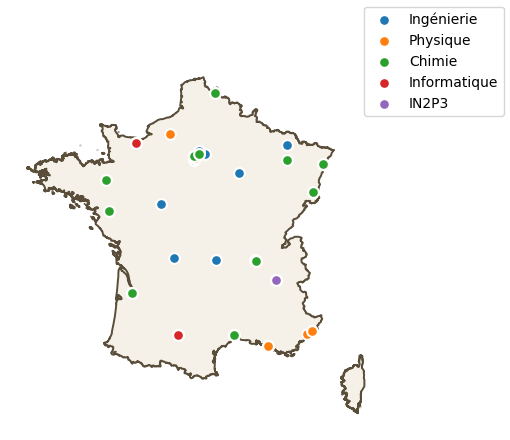

In [9]:
# display data on France map
category = 'Institut principal'

# display France borders
france = pygadm.Items(name="France")
#spain = pygadm.Items(name="Spain")
fig, ax = plt.subplots ()
france.plot (ax=ax, **france_props)

# scatter labs by category
categories = list (gdf_Labs [category].unique ())
for cate in categories:
    i = categories.index (cate)
    subset = gdf_Labs.loc [gdf_Labs [category].isin([cate])]
    # set marker properties
    marker_props = {
        'marker': "o",
        'color': f'C{i}',
        'markersize': 60,
        'edgecolors': "white",
        'linewidths': 1.5,
        'zorder': 5,
        }
    subset.plot(
        ax=ax,
        **marker_props,
        label = cate
    )


# fig properties
fig.legend ()
ax.set_aspect (1.5)
plt.axis ('off')
fig_id = 'france'

#rt.save_figure (fig, path2figures + fig_id, ['png', 'svg'])

## Using GeoPandas.explore()

In [10]:
gdf_Labs.explore (column = category,
                 popup = True,
                 marker_kwds = {'radius': 5},
                 cmap = 'Set1')

---
# Brouillon

In [21]:
# temp : list of unique labcodes for claude to collect their address
toto = ''
for i in list ( gdf_Labs ['UMR/UPR'].unique ()):
    toto += f'{i}, '
toto

'UMR5005, UMR9001, UPR8011, UMR6252, UMR7325, UMR5085, UMR7073, UMR6508, UMR5130, UMR9007, UMR5269, UMR8507, UMR8635, IRL2958, UMR6634, UMR7347, UMR6072, UMR7177, UMR5026, UMR7357  , UMR5635, UMR8520, UMR5214, UMR7198, UMR8180, UMR7334, UMR6502, UMR5218, UMR5270, UMR7010, UMR7588, UMR6602, UMR5256, UMR8247, UMR7361, UMR6226, UMR5221, UMR7076, UPR8001, UMR5213, UMR5628, UMR5615, UMR7341, UMR5821, UMR7642, UPR3407 , UMR5129, UMR9024, UPR2940, UMR7345, UMR8029, UMR5266, UMR8181, UMR7252, '

In [45]:
# display data on France map
category = 'Institut principal'

# scatter labs by category
categories = list (gdf_Labs [category].unique ())
for cate in categories:
    i = categories.index (cate)
    subset = gdf_Labs.loc [gdf_Labs [category].isin([cate])]
    # set marker properties
    marker_props = {
        'marker': "o",
        'color': f'C{i}',
        'markersize': 60,
        'edgecolors': "white",
        'linewidths': 1.5,
        'zorder': 5
        }
    subset.explore ()
    
#rt.save_figure (fig, path2figures + fig_id, ['png', 'svg'])

---
# Brouillon

In [3]:
# ── Villes à afficher (nom : longitude, latitude) ────────────────────────────
villes = {
    "Paris":      ( 2.3522,  48.8566),
    "Lyon":       ( 4.8357,  45.7640),
    "Strasbourg": ( 7.7521,  48.5734),
    "Marseille":  ( 5.3698,  43.2965),
    "Bordeaux":   (-0.5792,  44.8378),
    "Lille":      ( 3.0573,  50.6292),
    "Nantes":     (-1.5534,  47.2184),
    "Toulouse":   ( 1.4442,  43.6047),
    "Nice":       ( 7.2620,  43.7102),
    "Rennes":     (-1.6778,  48.1173),
}

gdf_villes = gpd.GeoDataFrame(
    {"nom": list(villes.keys())},
    geometry=[Point(lon, lat) for lon, lat in villes.values()],
    crs="EPSG:4326",
)

# France
france.plot(ax=ax, **france_props)



NameError: name 'france' is not defined

NameError: name 'france' is not defined

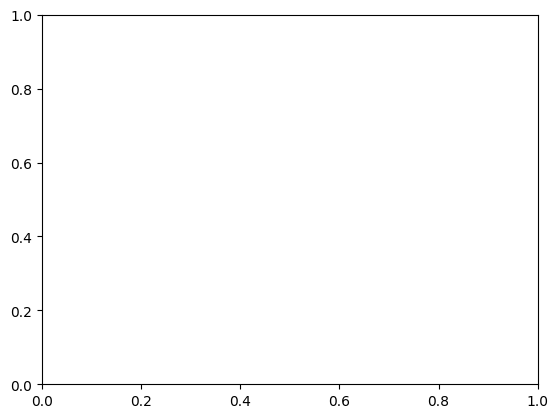

In [4]:
fig, ax = plt.subplots ()
france.plot (ax=ax, **france_props)
# Points des villes

gdf_villes.plot(
    ax=ax,
    **marker_props
)
ax.set_aspect (1.5)